In [1]:
%load_ext autoreload
%autoreload 2
from loguru import logger
import sys

In [2]:
from evaluation_utils import TaxonomyEvaluator
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np

In [3]:
logger.remove()
logger.add(sys.stderr, level="INFO")

1

In [4]:
folder = "results"
ground_truth_folder = "data"
llms = ["gpt-4o-mini", "gpt-4o", "Meta-Llama-3.1-8B-Instruct", "Meta-Llama-3.1-70B-Instruct", "qwq-32b"]
llm_labels = [
    "GPT-4o-mini", "GPT-4o", "Llama3.1-8B", "Llama3.1-70B", "QwQ-32B"
]

dataset = "wordnet"
num_generations = range(1, 11)
ground_truth_path = f"{ground_truth_folder}/{dataset}.csv"

In [5]:
def cohen_d(x,y):
    return (np.mean(x) - np.mean(y)) / np.sqrt((np.std(x, ddof=1) ** 2 + np.std(y, ddof=1) ** 2) / 2.0)

In [8]:
llm_results = {}
for llm in llms:
    results = {
        "con": [],
        "incon": []
    }    
    folder_path = f"{folder}/{llm}"
    for num_generation in tqdm(num_generations):
        evaluator = TaxonomyEvaluator(
            folder_path,
            dataset,
            ground_truth_path,
            num_generation,
            filenames=[f"{folder_path}/{dataset}/results_{num_generation}.csv"],
        )

        cleaned_df = evaluator.generate_merged_results(1, "mv", dataset=dataset)
        evaluation_results = evaluator.evaluate_taxonomies(
            cleaned_df, dataset, return_value="all"
        )
        # print(len(evaluation_results["f1"]))
        num_samples = len(evaluation_results["f1"])
        f1_con = np.mean(
            [
                evaluation_results["f1"][i]
                for i in range(num_samples)
                if evaluation_results["consistency"][i]
            ]
        )
        f1_incon = np.mean(
            [
                evaluation_results["f1"][i]
                for i in range(num_samples)
                if not evaluation_results["consistency"][i]
            ]
        )
        results["con"].append(f1_con)
        results["incon"].append(f1_incon)
    llm_results[llm] = results

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [9]:
num_generation = 10
abscon_result = {}
for llm in tqdm(llms):
    results = []
    folder_path = f"{folder}/{llm}"
    evaluator = TaxonomyEvaluator(folder_path, dataset, ground_truth_path, num_generation)
    df = pd.read_csv(f"{folder_path}/{dataset}/results_abscon_{num_generation}.csv")
    evaluation_results = evaluator.evaluate_taxonomies(df, dataset, return_value="avg")
    results = {
        "abscon": [evaluation_results["f1"]]
    }

    abscon_result[llm] = results

  0%|          | 0/5 [00:00<?, ?it/s]

In [10]:
import matplotlib.pyplot as plt
import numpy as np

In [11]:
## Plot the difference between consistent and non-consistent candidates
llm_results_categorization = {
    "abscon": [],
    "consistent": [],
    "inconsistent": []
}

for llm in llms:
    llm_results_categorization["abscon"].append(abscon_result[llm]["abscon"])
    llm_results_categorization["consistent"].append(llm_results[llm]["con"])
    llm_results_categorization["inconsistent"].append(llm_results[llm]["incon"])


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
plt.style.use(['science', "ieee"])


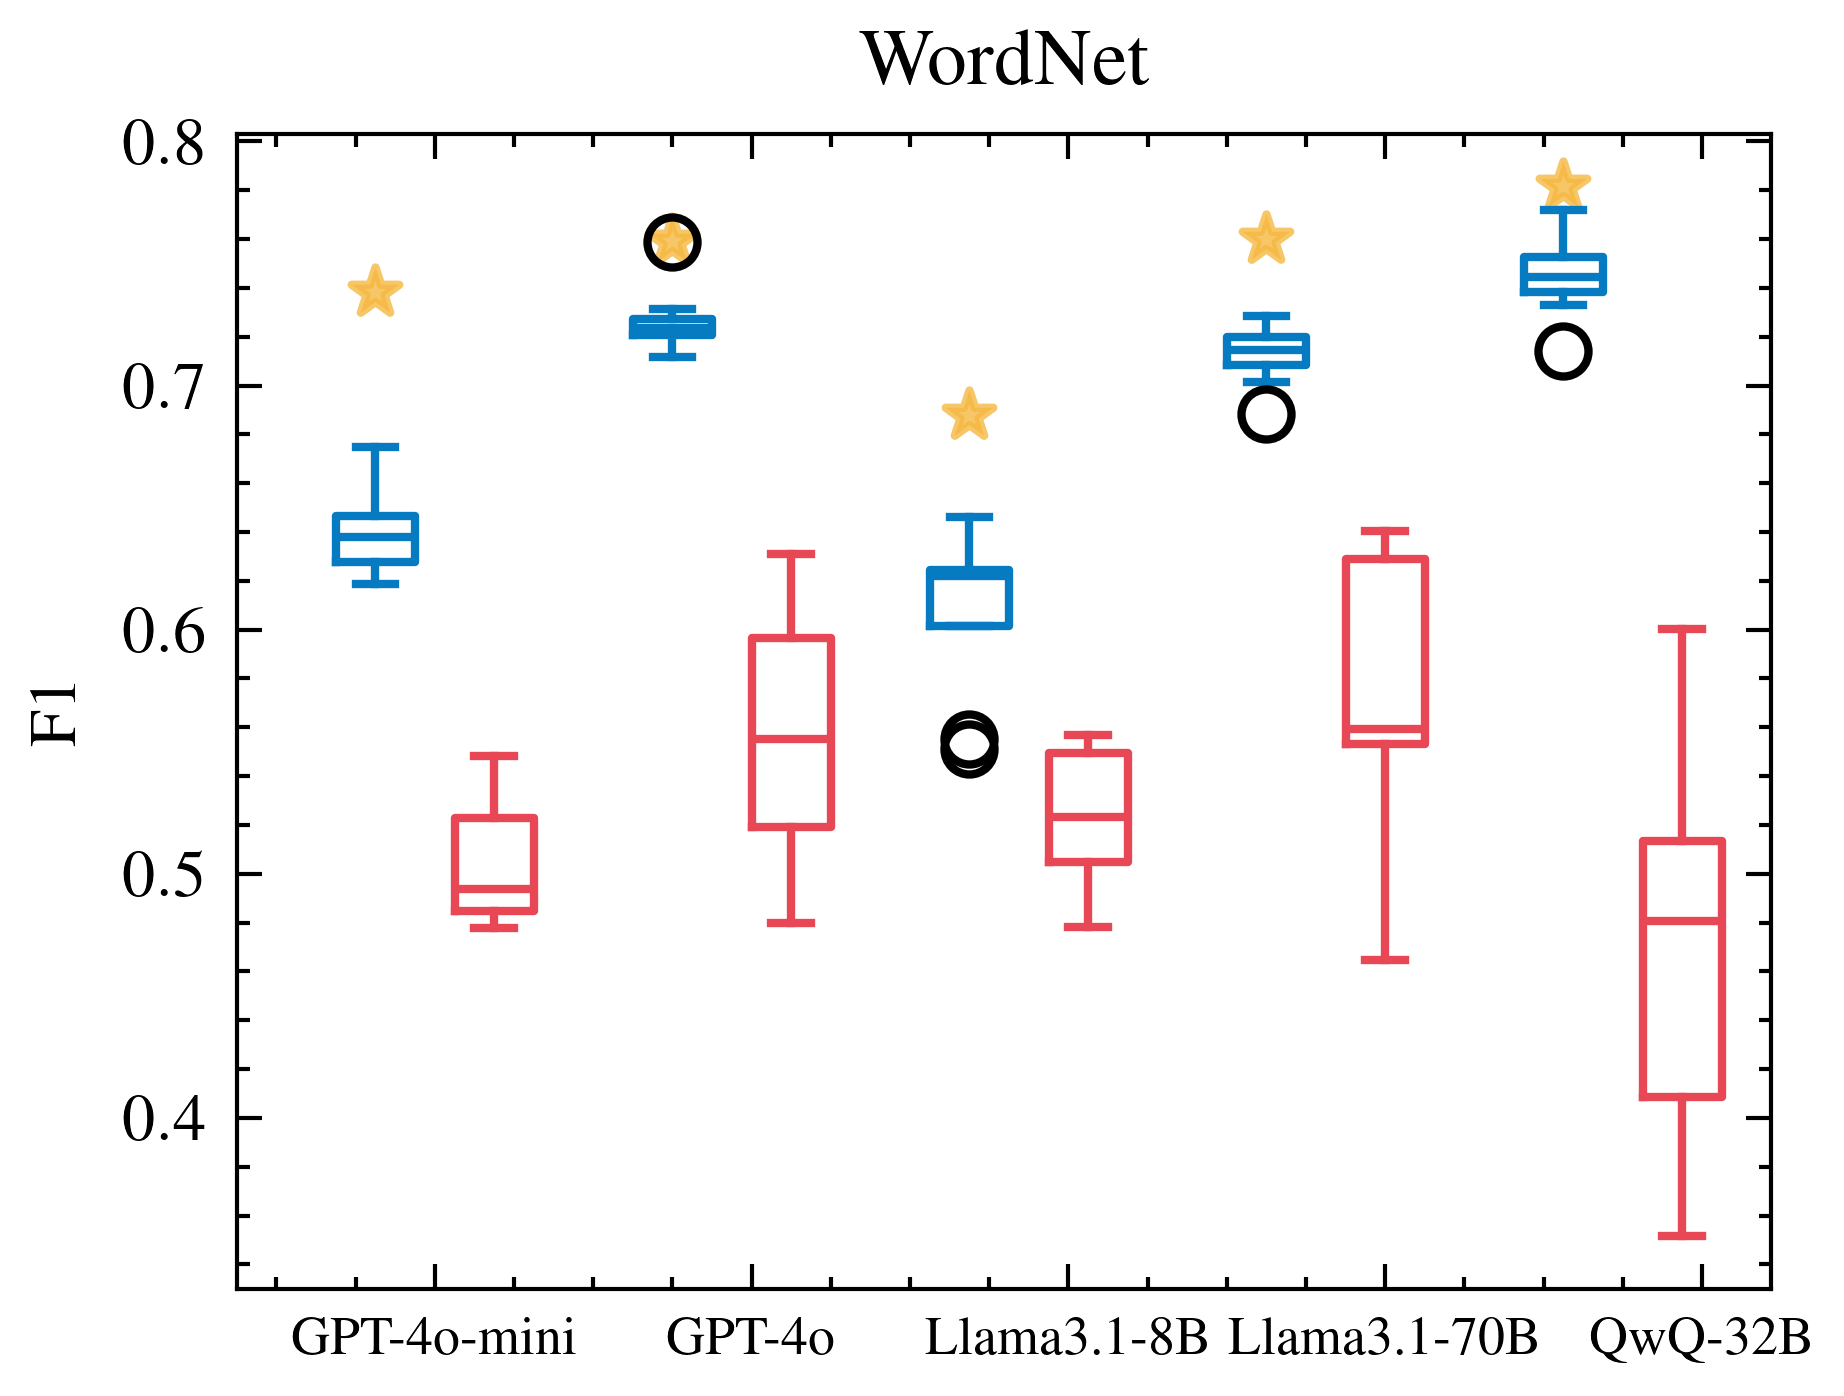

In [24]:
abscon_results = llm_results_categorization["abscon"]
# abscon_plot = plt.boxplot(abscon_results,
#                                positions=np.array(
#     np.arange(len(abscon_results)))*3.0-0.8,
#                                widths=0.8)

for i, abscon_result in enumerate(abscon_results):
    abscon_plot = plt.scatter(
        i * 3.0 - 0.6,
        abscon_results[i],
        alpha=0.8,
        label="AbsCon" if i == 0 else None,
        marker="*",
        color="#F5B841",
        # s=100,        # default is ~36, so this is much bigger
        # zorder=3,     # optional: draws stars on top of the box lines
    )
consistent_results = llm_results_categorization["consistent"]
consistent_plot = plt.boxplot(
    consistent_results,
    positions=np.array(np.arange(len(consistent_results))) * 3.0 - 0.6,
    widths=0.8,
)

inconsistent_results = llm_results_categorization["inconsistent"]
inconsistent_plot = plt.boxplot(
    inconsistent_results,
    positions=np.array(np.arange(len(inconsistent_results))) * 3.0 + 0.6,
    widths=0.8,
)


def define_box_properties(plot_name, color_code, label):
    for k, v in plot_name.items():
        plt.setp(plot_name.get(k), color=color_code)

    # use plot function to draw a small line to name the legend.
    plt.plot([], c=color_code, label=label)
    # plt.legend()
# plt.legend()

# setting colors for each groups
# define_box_properties(abscon_plot, '#F5B841', 'AbsCon')
define_box_properties(consistent_plot, "#067BC2", "Consistent")
define_box_properties(inconsistent_plot, "#E84855", "Inconsistent")

plt.xticks(np.arange(0, len(llm_labels) * 3.2, 3.2), llm_labels, fontsize=6.5)
plt.xlim(-2, len(llm_labels) * 2.7)
# plt.xticks(np.arange(len(llm_labels)) * 3.0, llm_labels,
#            rotation=5, ha="right", rotation_mode="anchor")

plt.ylabel("F1")
plt.title("WordNet")
plt.savefig(f"WordNet.pdf", dpi=300)
plt.show()

In [18]:
from cliffs_delta import cliffs_delta, lookup_size
from scipy.stats import ranksums

In [19]:
statistical_test_results = []
for consistent_result, inconsistent_result in zip(consistent_results, inconsistent_results):
    statistical_test_results.append(ranksums(consistent_result, inconsistent_result, alternative="greater"))


In [20]:
statistical_test_results

[RanksumsResult(statistic=3.779644730092272, pvalue=7.852614211537559e-05),
 RanksumsResult(statistic=3.779644730092272, pvalue=7.852614211537559e-05),
 RanksumsResult(statistic=3.552866046286736, pvalue=0.00019052922602534277),
 RanksumsResult(statistic=3.779644730092272, pvalue=7.852614211537559e-05),
 RanksumsResult(statistic=3.779644730092272, pvalue=7.852614211537559e-05)]

In [21]:
dull = {'small': 0.147, 'medium': 0.33, 'large': 0.474} # effect sizes from (Hess and Kromrey, 2004)

In [22]:
cliffs_values = []
for consistent_result, inconsistent_result in zip(consistent_results, inconsistent_results):
    cliffs_values.append(cliffs_delta(consistent_result, inconsistent_result)[0])
mean_cliff = np.mean(cliffs_values)

In [23]:
cliffs_values

[1.0, 1.0, 0.94, 1.0, 1.0]

In [ ]:
mean_cliff

In [ ]:
lookup_size(mean_cliff, dull)